<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/Task05_Machine_Learning_01_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Display settings for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]
df['species_id'] = iris.target  # Numeric label for coloring

print("=== DATASET OVERVIEW ===")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\n=== BASIC STATISTICS ===")
print(df.describe())

print(f"\n=== SPECIES DISTRIBUTION ===")
print(df['species'].value_counts())

=== DATASET OVERVIEW ===
Shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species  species_id
0                5.1               3.5                1.4               0.2  setosa           0
1                4.9               3.0                1.4               0.2  setosa           0
2                4.7               3.2                1.3               0.2  setosa           0
3                4.6               3.1                1.5               0.2  setosa           0
4                5.0               3.6                1.4               0.2  setosa           0

=== BASIC STATISTICS ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  species_id
count         150.000000        150.000000         150.000000        150.000000  150.000000
mean            5.843333          3.057333           3.758000          1.199333    1.000000
std             0.828066          0.435866           1.765298     

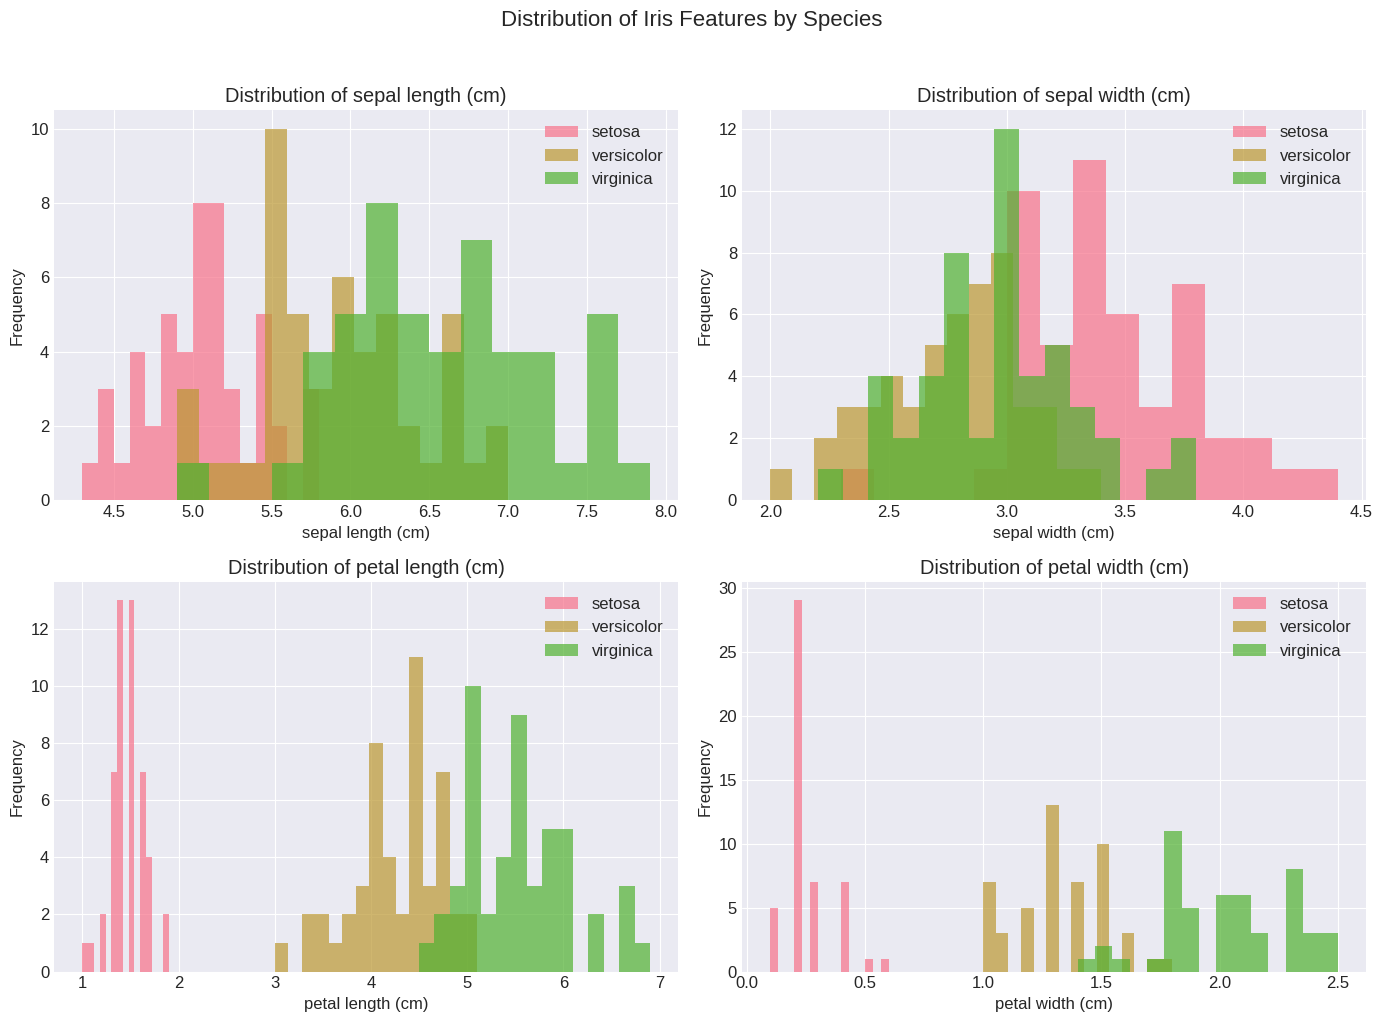

In [ ]:
# Graph 1: Distribution of each feature across species
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = df.columns[:-2]  # Exclude species and species_id

for idx, feature in enumerate(features):
    row, col = idx // 2, idx % 2
    for species in df['species'].unique():
        data = df[df['species'] == species][feature]
        axes[row, col].hist(data, alpha=0.7, label=species, bins=15)
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()

plt.suptitle('Distribution of Iris Features by Species', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

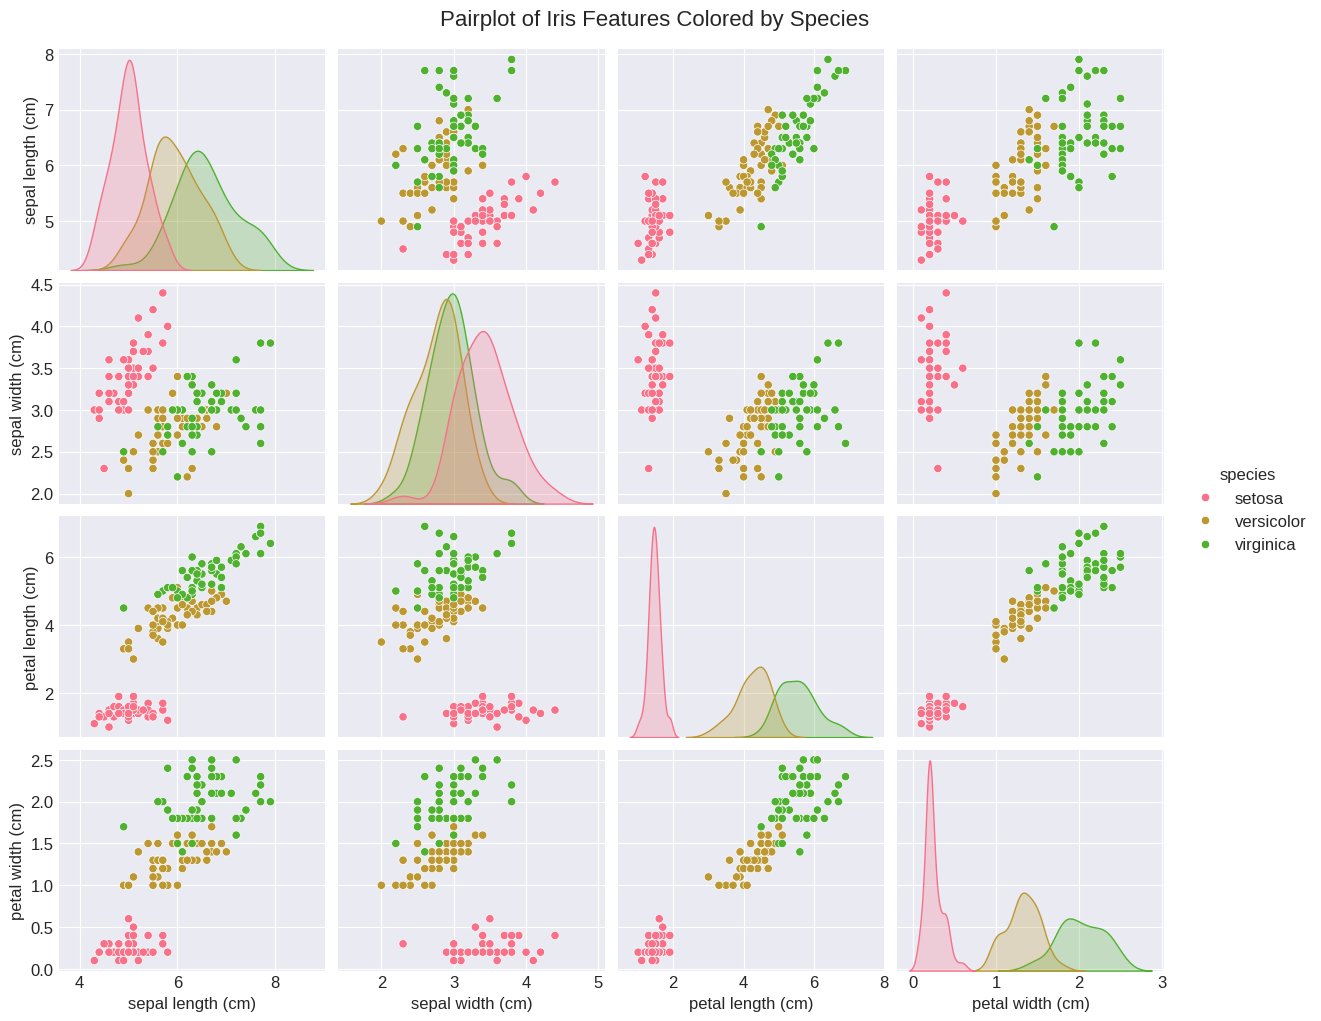

In [ ]:
# Graph 2: Pairplot showing relationships between features
# This is one of the most informative plots for Iris dataset
fig = plt.figure(figsize=(12, 10))
g = sns.pairplot(df, hue='species', vars=features, height=2.5, aspect=1.2)
g.fig.suptitle('Pairplot of Iris Features Colored by Species', y=1.02, fontsize=16)
plt.show()

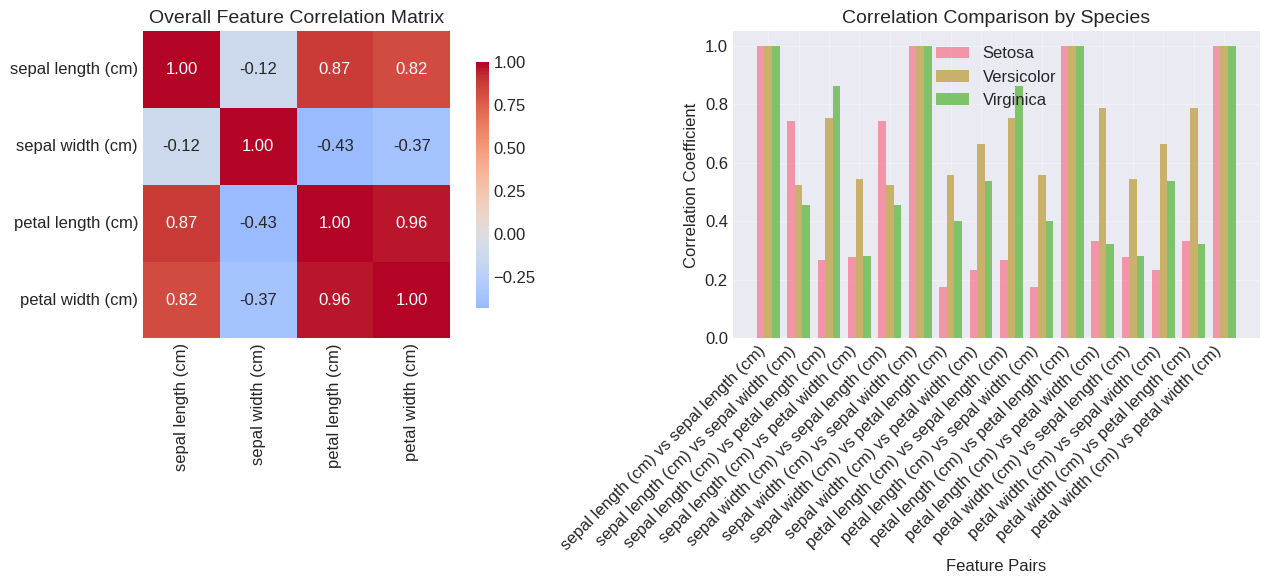

In [ ]:
# Graph 3: Correlation heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Overall correlation
correlation_matrix = df[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, ax=ax1, cbar_kws={'shrink': 0.8})
ax1.set_title('Overall Feature Correlation Matrix', fontsize=14)

# Correlation by species
species_list = df['species'].unique()
correlations = {}
for species in species_list:
    species_data = df[df['species'] == species][features]
    correlations[species] = species_data.corr()

# Plot correlation for each species as heatmap
# Combine into one figure
combined_corr = pd.concat([correlations['setosa'].stack(),
                          correlations['versicolor'].stack(),
                          correlations['virginica'].stack()],
                         keys=['Setosa', 'Versicolor', 'Virginica'], axis=1)
combined_corr.columns = ['Setosa', 'Versicolor', 'Virginica']

# Get feature pairs
feature_pairs = [f'{pair[0]} vs {pair[1]}' for pair in correlations['setosa'].stack().index]

# Create bar plot for comparisons
x = np.arange(len(feature_pairs))
width = 0.25

for i, (species, color) in enumerate(zip(['Setosa', 'Versicolor', 'Virginica'], ['blue', 'green', 'red'])):
    ax2.bar(x + i*width, combined_corr[species], width, label=species, alpha=0.7)

ax2.set_xlabel('Feature Pairs')
ax2.set_ylabel('Correlation Coefficient')
ax2.set_title('Correlation Comparison by Species', fontsize=14)
ax2.set_xticks(x + width)
ax2.set_xticklabels(feature_pairs, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

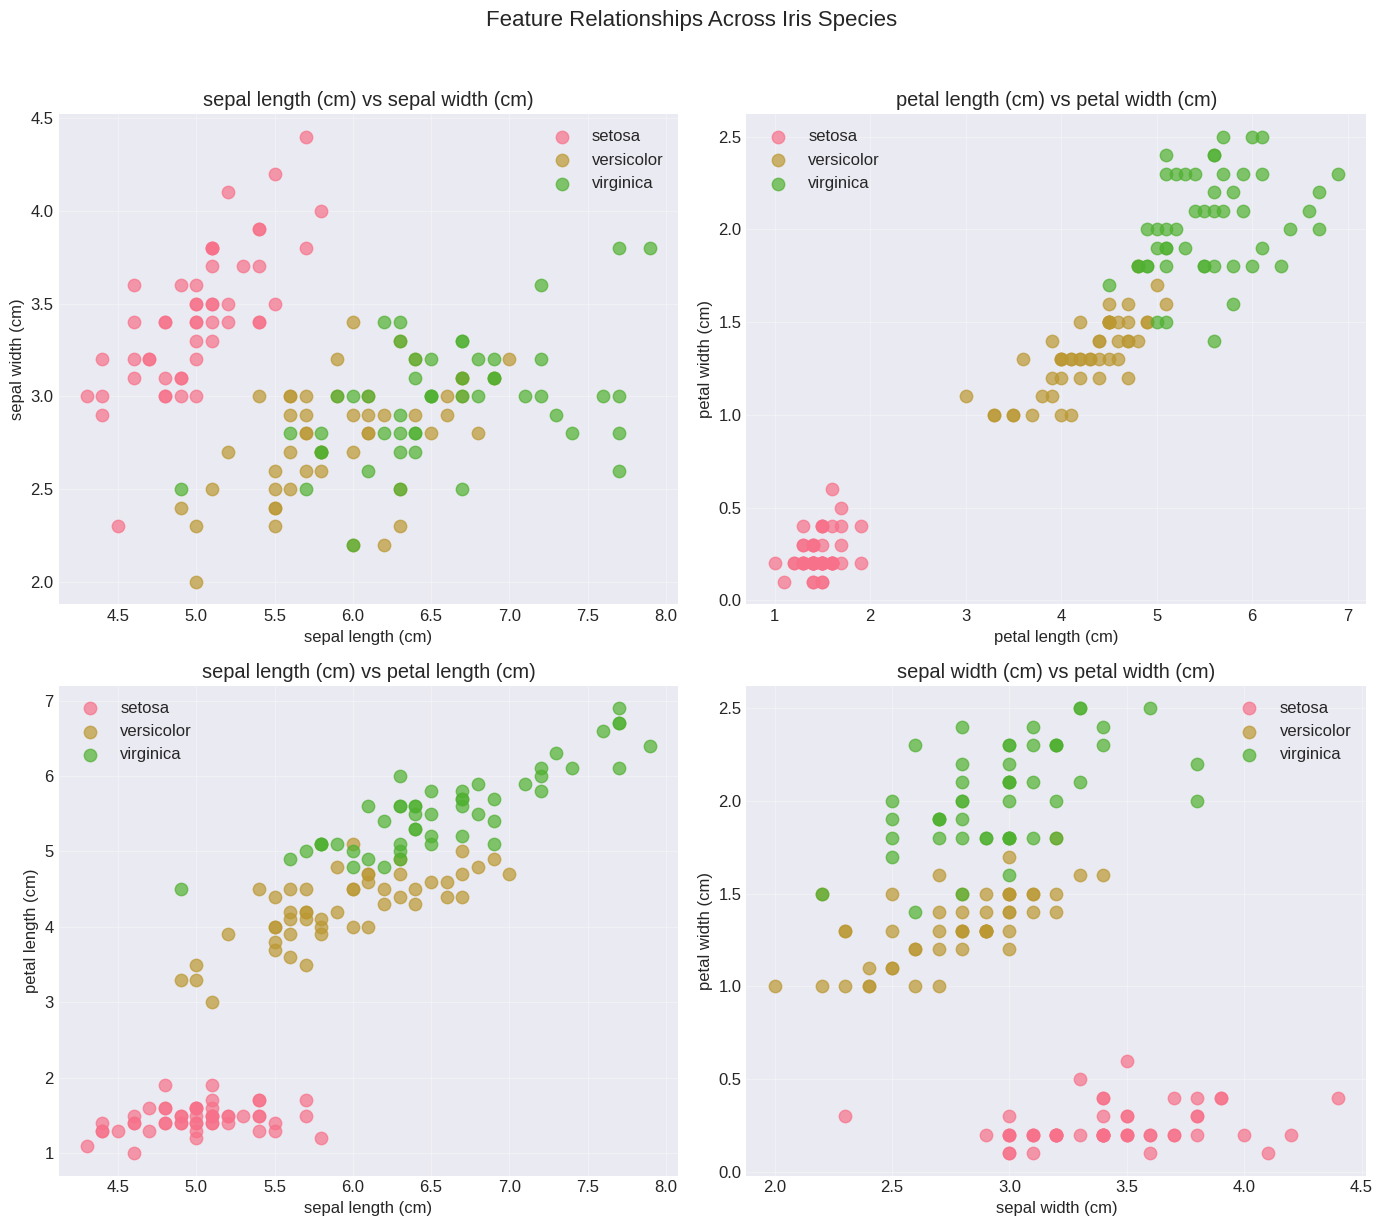

In [ ]:
# Graph 4: Scatter plots showing feature relationships with species
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Create scatter plots for different feature combinations
feature_pairs = [('sepal length (cm)', 'sepal width (cm)'),
                ('petal length (cm)', 'petal width (cm)'),
                ('sepal length (cm)', 'petal length (cm)'),
                ('sepal width (cm)', 'petal width (cm)')]

for idx, (x_feature, y_feature) in enumerate(feature_pairs):
    row, col = idx // 2, idx % 2

    # Scatter plot
    for species in df['species'].unique():
        species_data = df[df['species'] == species]
        axes[row, col].scatter(species_data[x_feature],
                              species_data[y_feature],
                              label=species, alpha=0.7, s=80)

    axes[row, col].set_xlabel(x_feature)
    axes[row, col].set_ylabel(y_feature)
    axes[row, col].set_title(f'{x_feature} vs {y_feature}')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.suptitle('Feature Relationships Across Iris Species', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

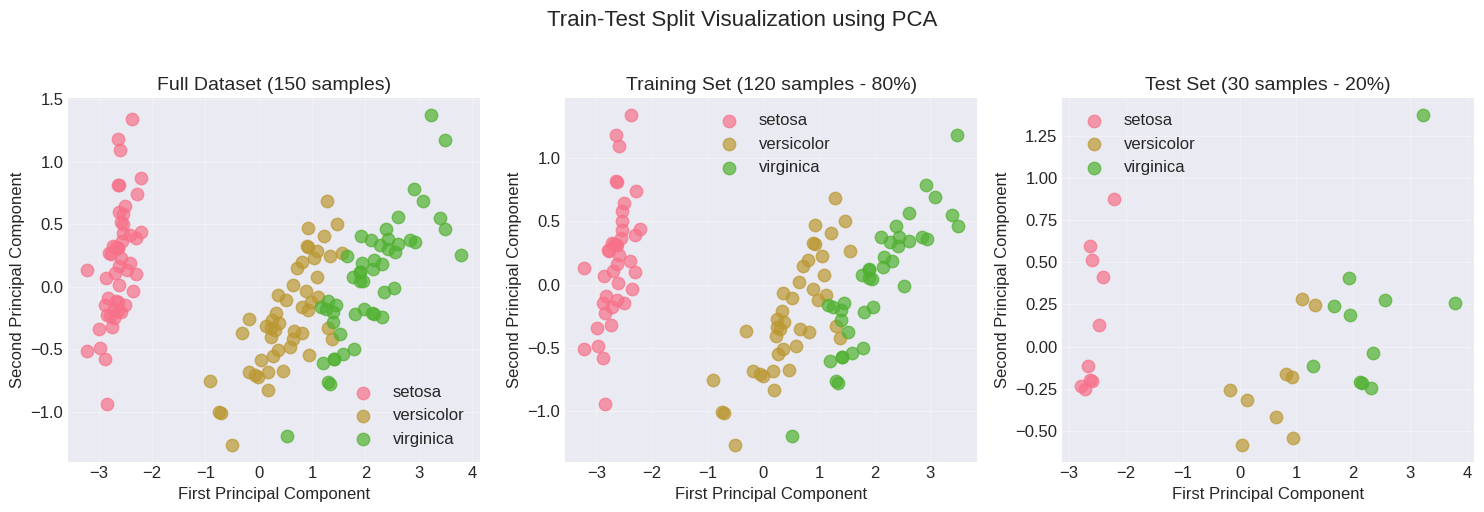


Training samples: 120 (80%)
Test samples: 30 (20%)
Total samples: 150 (100%)


In [ ]:
# Graph 5: Visualizing the train-test split
from sklearn.decomposition import PCA

# Perform PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df[features])
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['species'] = df['species']
df_pca['split'] = 'Full Dataset'

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    df[features], df['species'], test_size=0.2, random_state=42
)

# Apply same PCA transformation to training and test
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

# Create the visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Full dataset
for species in df['species'].unique():
    species_data = df_pca[df_pca['species'] == species]
    axes[0].scatter(species_data['PC1'], species_data['PC2'],
                   label=species, alpha=0.7, s=80)
axes[0].set_title('Full Dataset (150 samples)', fontsize=14)
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Training set
for species in df['species'].unique():
    idx_train = y_train[y_train == species].index
    axes[1].scatter(X_train_pca[y_train == species, 0],
                   X_train_pca[y_train == species, 1],
                   label=species, alpha=0.7, s=80)
axes[1].set_title(f'Training Set ({len(X_train)} samples - 80%)', fontsize=14)
axes[1].set_xlabel('First Principal Component')
axes[1].set_ylabel('Second Principal Component')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Test set
for species in df['species'].unique():
    idx_test = y_test[y_test == species].index
    axes[2].scatter(X_test_pca[y_test == species, 0],
                   X_test_pca[y_test == species, 1],
                   label=species, alpha=0.7, s=80)
axes[2].set_title(f'Test Set ({len(X_test)} samples - 20%)', fontsize=14)
axes[2].set_xlabel('First Principal Component')
axes[2].set_ylabel('Second Principal Component')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Train-Test Split Visualization using PCA', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nTraining samples: {len(X_train)} (80%)")
print(f"Test samples: {len(X_test)} (20%)")
print(f"Total samples: {len(df)} (100%)")

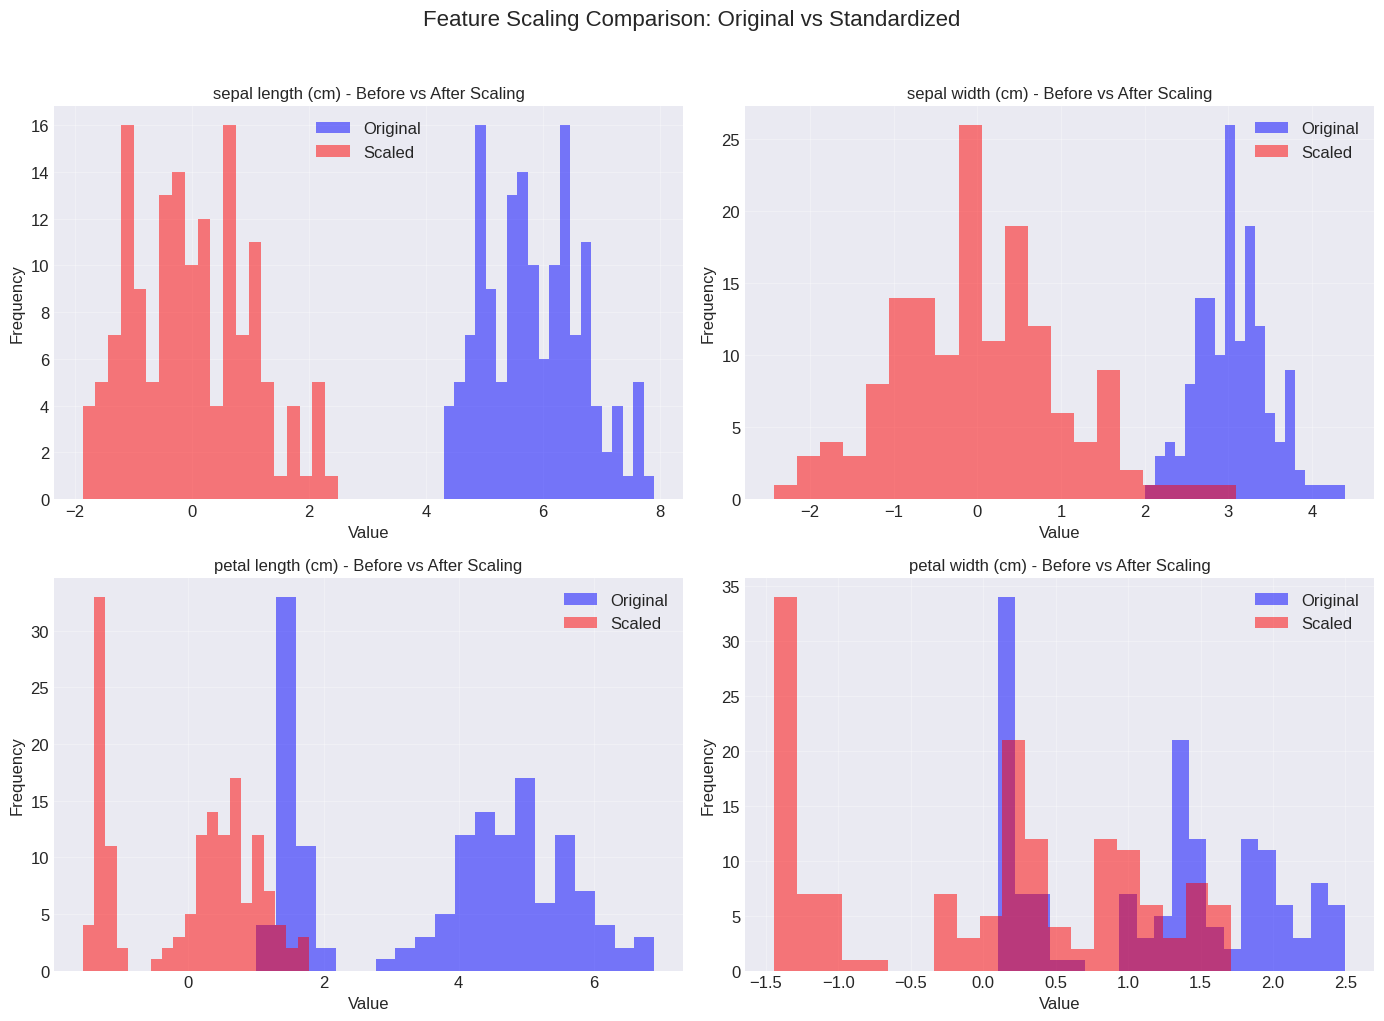


=== SCALING STATISTICS COMPARISON ===

Original data statistics:
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
mean           5.843333          3.057333           3.758000          1.199333
std            0.828066          0.435866           1.765298          0.762238

Scaled data statistics:
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
mean      -1.468455e-15     -1.823726e-15      -1.610564e-15     -9.473903e-16
std        1.003350e+00      1.003350e+00       1.003350e+00      1.003350e+00


In [ ]:
# Graph 6: Comparison of original vs scaled features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Create scaler and transform data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Plot original and scaled distributions
for idx, feature in enumerate(features):
    row, col = idx // 2, idx % 2

    # Original data
    axes[row, col].hist(df[feature], alpha=0.5, label='Original', bins=20, color='blue')

    # Scaled data (using the same feature index)
    # The 'idx' from enumerate is already the correct index for X_scaled columns
    axes[row, col].hist(X_scaled[:, idx], alpha=0.5, label='Scaled', bins=20, color='red')

    axes[row, col].set_title(f'{feature} - Before vs After Scaling', fontsize=12)
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.suptitle('Feature Scaling Comparison: Original vs Standardized', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Show statistics comparison
print("\n=== SCALING STATISTICS COMPARISON ===")
print("\nOriginal data statistics:")
print(df[features].describe().loc[['mean', 'std']])

print("\nScaled data statistics:")
scaled_df = pd.DataFrame(X_scaled, columns=features)
print(scaled_df.describe().loc[['mean', 'std']])

/tmp/ipykernel_948/4224855573.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row, col].boxplot([X_train.iloc[:, idx], X_train_scaled[:, idx]],
/tmp/ipykernel_948/4224855573.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row, col].boxplot([X_train.iloc[:, idx], X_train_scaled[:, idx]],
/tmp/ipykernel_948/4224855573.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[row, col].boxplot([X_train.iloc[:, idx], X_train_scaled[:, idx]],
/tmp/ipykernel_948/4224855573.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support

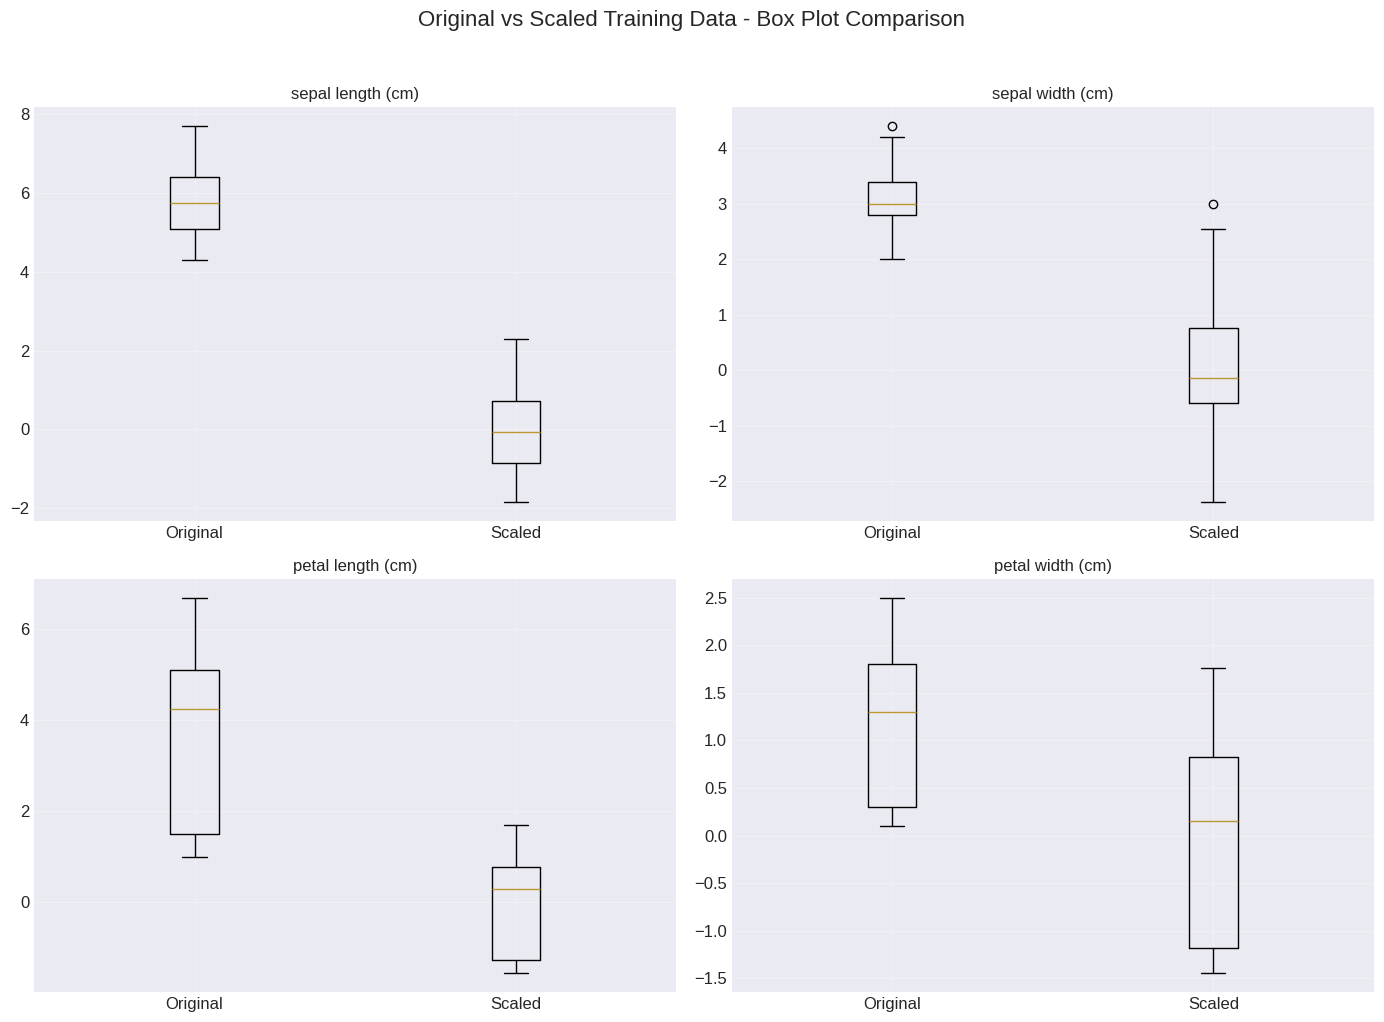


=== PIPELINE RESULTS ===
Training data shape: (120, 4)
Test data shape: (30, 4)
Training target shape: (120,)
Test target shape: (30,)

=== DATA READY FOR MODELING (NEXT LAB!) ===
Training data ready. Shape: (120, 4)
Test data ready. Shape: (30, 4)


In [ ]:


def prepare_iris_data_with_viz(test_size=0.2, random_state=42):
    """
    Complete data preparation pipeline for Iris dataset with visualizations.

    Parameters:
    test_size: float, proportion of data to use for testing
    random_state: int, random seed for reproducibility

    Returns:
    X_train_scaled, X_test_scaled, y_train, y_test, scaler
    """
    # 1. Load data
    iris = load_iris()
    df = pd.DataFrame(iris.data, columns=iris.feature_names)

    # 2. Separate features and target
    X = df.iloc[:, :-1] if len(df.columns) > 4 else df
    y = iris.target

    # 3. Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # 4. Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 5. Visualize scaling effect on training data
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for idx, feature in enumerate(X.columns):
        row, col = idx // 2, idx % 2

        # Compare original vs scaled
        axes[row, col].boxplot([X_train.iloc[:, idx], X_train_scaled[:, idx]],
                              labels=['Original', 'Scaled'])
        axes[row, col].set_title(f'{feature}', fontsize=12)
        axes[row, col].grid(True, alpha=0.3)

    plt.suptitle('Original vs Scaled Training Data - Box Plot Comparison', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

# Run the pipeline
X_train_scaled, X_test_scaled, y_train, y_test, scaler = prepare_iris_data_with_viz()

print("\n=== PIPELINE RESULTS ===")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")

print("\n=== DATA READY FOR MODELING (NEXT LAB!) ===")
print("Training data ready. Shape:", X_train_scaled.shape)
print("Test data ready. Shape:", X_test_scaled.shape)